In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [10]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/corneliusozoji/housing-dataset/housing.csv


In [12]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/corneliusozoji/housing-dataset/housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [13]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [15]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(
    df['total_bedrooms'].median()
)

In [16]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [19]:
X = df[['longitude',
        'latitude',
        'housing_median_age',
        'total_rooms',
        'total_bedrooms',
        'population',
        'households',
        'median_income']]

y = df['median_house_value']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 8)
Testing data: (4128, 8)


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [23]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,longitude,-42632.391717
1,latitude,-42450.071864
2,housing_median_age,1182.809649
3,total_rooms,-8.187977
4,total_bedrooms,116.260128
5,population,-38.492213
6,households,46.342572
7,median_income,40538.404387


In [24]:
y_pred = model.predict(X_test)

In [25]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
20046,47700.0,63736.591338
3024,45800.0,154344.594319
15663,500001.0,253073.194287
20484,218600.0,263507.746536
9814,278000.0,266883.359611
13311,158700.0,155403.494466
7113,198200.0,287058.654200
7668,157500.0,223660.781552
18246,340000.0,257045.027183
5723,446600.0,404273.366113


In [26]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R-squared:", r2)

R-squared: 0.613866475643519


In [27]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 5059928371.1653385


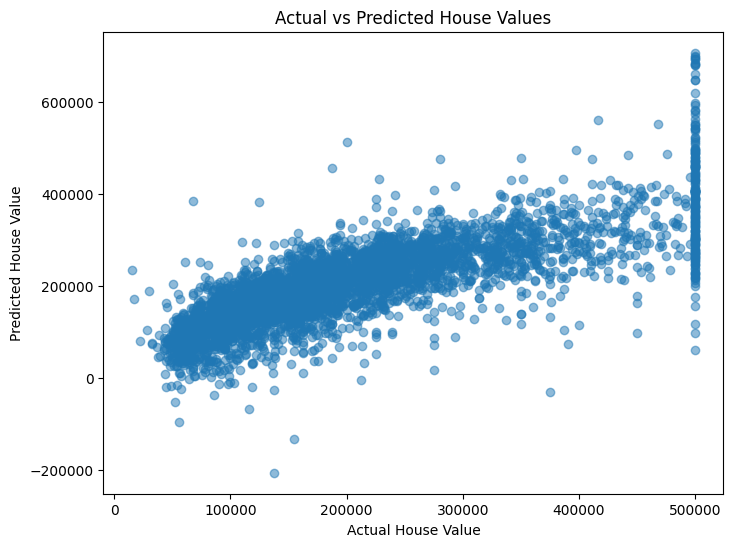

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Value")

plt.ylabel("Predicted House Value")

plt.title("Actual vs Predicted House Values")

plt.show()

A Linear Regression model developed to predict California housing prices using housing-related features such as median income, housing age, number of rooms, population, and location information. The dataset was divided into training and testing sets, and the model was trained using Scikit-learn.

The model coefficients were analyzed to understand the relationship between housing features and median house values. Features with positive coefficients showed a positive relationship with house prices, while negative coefficients indicated an inverse relationship.

Model performance was evaluated using R-squared (R²) and Mean Squared Error (MSE). The R² score measured how well the model explained variations in housing prices, while MSE measured the average prediction error.

Overall, the Linear Regression model provided a baseline approach for predicting house prices and demonstrated how statistical modeling can be used to understand factors influencing real estate values.

CODVEDA INTERNSHIP PROJECT 2 Regression Analysis BY OZOJI CRNELIUS OGECHUKWU